# COMP3202 – Introduction to Machine Learning
# Lab 1: Know Your Group and Your Data



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()  # nicer default look for every plot below, one line, set once

# Part 1 — Meet Your Group
Introduce yourselves, exchange contact information and create a shared GitHub repository or shared folder for the semester.




**Group Number:**

**Group Members:**
1.  
2.  
3.  


# Part 2 — Find Your Dataset(s)
For each dataset record the required information.


## Classification Dataset

- Dataset name: Pima Indians Diabetes Database
- Source: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
- Application/domain: Medical diagnosis — predicting diabetes onset from clinical measurements
- Number of samples: 768
- Number of features: 8
- Prediction target: Outcome (0 = no diabetes, 1 = diabetes)
- Task type: Classification

Record:
*   dataset name;
*   source (URL);
*   application/domain;
*   number of samples;
*   number of features;
*   prediction target;
*   whether the task is regression or classification.

## Regression Dataset

- Dataset name: California Housing Dataset
- Source: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
- Application/domain: Real estate — predicting median house value from census block group demographics and geography
- Number of samples: 20,640
- Number of features: 8
- Prediction target: MedHouseVal (median house value, in $100,000s)
- Task type: Regression

Record:
*   dataset name;
*   source (URL);
*   application/domain;
*   number of samples;
*   number of features;
*   prediction target;
*   whether the task is regression or classification.

# Part 3 — Exploratory Data Analysis

For every dataset, compute

*   dataset dimensions;
*   data types of each feature;
*   number of missing values;
*   number of duplicate rows;
*   summary statistics (mean, median, minimum, maximum, standard deviation);
*   class distribution (classification datasets);
*   distribution of the target variable (regression datasets).

## Classification Dataset
Load your dataset below.

In [2]:
diabetes = pd.read_csv("datasets/diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Dataset Overview

In [3]:
print("Shape:", diabetes.shape)
diabetes.info()
diabetes.describe(include='all')

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Missing Values and Duplicates

In [4]:
print(diabetes.isnull().sum())
print("\nDuplicate rows:", diabetes.duplicated().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0


The `isnull()` check above doesn't catch this dataset's real missing-value issue: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` use `0` as a placeholder for missing values (a living patient can't actually have a value of 0 for any of these). Checking directly:

In [5]:
suspect_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (diabetes[suspect_cols] == 0).sum()
zero_counts

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Interpretation: `SkinThickness` (227/768, ~30%) and `Insulin` (374/768, ~49%) are affected the most, `BloodPressure` (35) and `BMI` (11) less so, and `Glucose` only 5. These are the columns that will need imputation (e.g. median) before modelling, not the 0-missing-values `isnull()` reported.

## Regression Dataset
Load your dataset below.

In [6]:
housing = pd.read_csv("datasets/california_housing.csv")
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Dataset Overview

In [7]:
print("Shape:", housing.shape)
housing.info()
housing.describe(include='all')

Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Missing Values and Duplicates

In [8]:
print(housing.isnull().sum())
print("\nDuplicate rows:", housing.duplicated().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate rows: 0


# Part 4 — Exploratory Visualizations

Produce at least three meaningful visualizations in total across both datasets. Examples include

*   histograms;
*   box plots;
*   violin plots;
*   scatter plots;
*   pair plots;
*   correlation heatmaps;
*   class distribution charts.

For each visualization, briefly explain what you observe.

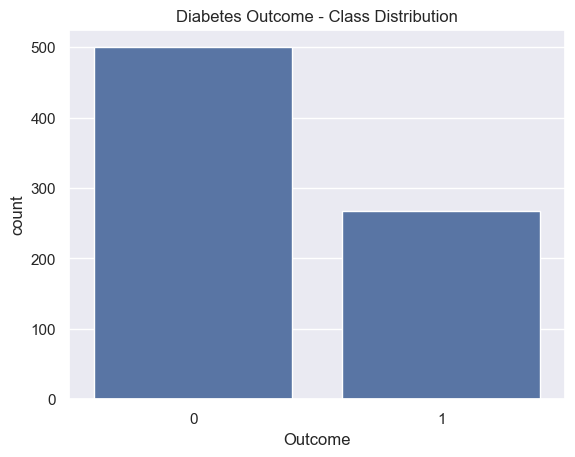

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [9]:
sns.countplot(data=diabetes, x="Outcome")
plt.title("Diabetes Outcome - Class Distribution")
plt.show()

print(diabetes["Outcome"].value_counts())
print(diabetes["Outcome"].value_counts(normalize=True))

Interpretation: The classes are imbalanced — 500 patients (65%) with no diabetes vs. 268 (35%) with diabetes. Not extreme, but worth keeping in mind later: accuracy alone would be a misleading metric, and a train/test split should be stratified to preserve this ratio.

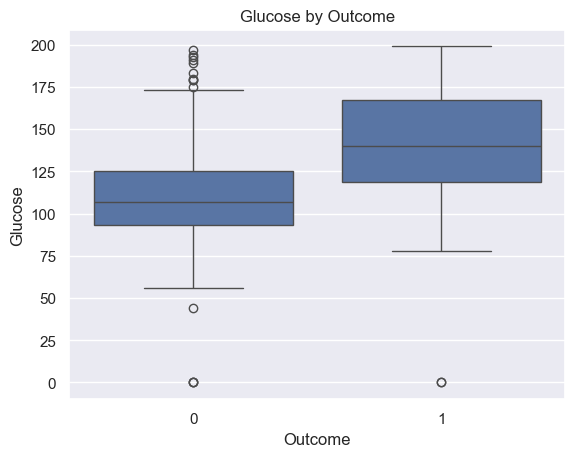

         Glucose  BloodPressure
Outcome                        
0          107.0           70.0
1          140.0           74.0

Glucose-Outcome correlation: 0.46658139830687406


In [10]:
sns.boxplot(data=diabetes, x="Outcome", y="Glucose")
plt.title("Glucose by Outcome")
plt.show()

print(diabetes.groupby("Outcome")[["Glucose", "BloodPressure"]].median())
print()
print("Glucose-Outcome correlation:", diabetes["Glucose"].corr(diabetes["Outcome"]))

Interpretation: Median glucose is clearly higher for diabetic patients (140) than non-diabetic patients (107) — the two boxes barely overlap, so `Glucose` looks like a strong predictor (correlation with Outcome ≈ 0.47). For comparison, `BloodPressure` medians are almost identical between classes (70 vs. 74), so not every feature is equally useful — `Glucose` stands out.

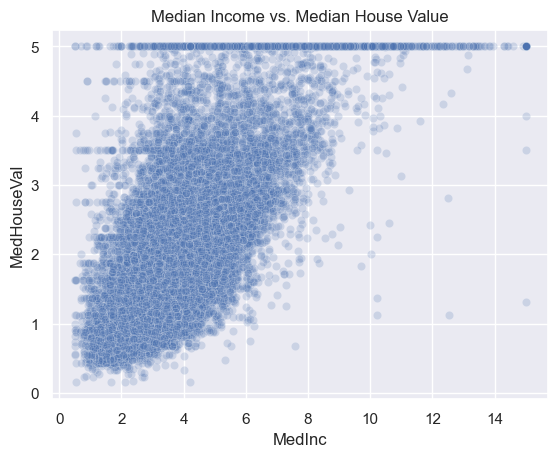

MedInc-MedHouseVal correlation: 0.6880752079585477
AveRooms-AveBedrms correlation: 0.8476213257130447
Max MedHouseVal (top-coding cap): 5.00001


In [11]:
sns.scatterplot(data=housing, x="MedInc", y="MedHouseVal", alpha=0.2)
plt.title("Median Income vs. Median House Value")
plt.show()

print("MedInc-MedHouseVal correlation:", housing["MedInc"].corr(housing["MedHouseVal"]))
print("AveRooms-AveBedrms correlation:", housing["AveRooms"].corr(housing["AveBedrms"]))
print("Max MedHouseVal (top-coding cap):", housing["MedHouseVal"].max())

Interpretation: There is a clear positive relationship between income and house value (correlation ≈ 0.69) — higher-income block groups tend to have higher median house values. The flat line of points along the top of the plot (at MedHouseVal = 5.00001) is the target being capped/top-coded by the census data, not a real pattern — a data quality issue to account for later.

# Part 5 — Discussion Questions
Answer the following questions.

*   Why did your group choose these dataset(s)?
*   What machine learning problem(s) are being solved?
*   What challenges do you expect?
*   Do you believe the dataset(s) contain enough information for machine learning to perform well? Explain.
*   What additional preprocessing might be required before training a model?

**Why did your group choose these dataset(s)?**
_(Personalize this one — it's asking for your group's actual reasoning. Draft: we chose the Pima Indians Diabetes dataset for classification because it's a well-documented, clinically meaningful binary problem with a manageable number of features, and the California Housing dataset for regression because it offers a large sample size and real-world features for predicting a continuous target — together they let us practice both classification and regression on genuinely different kinds of data.)_

**What machine learning problem(s) are being solved?**
Binary classification (predicting diabetes diagnosis from clinical measurements) and regression (predicting median house value from census block group features).

**What challenges do you expect?**
For diabetes: class imbalance (65%/35%) and missing values encoded as 0 in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` (up to 49% of rows for `Insulin`). For housing: the target is top-coded/capped at 5.00001, and several features (`AveRooms`, `AveBedrms`, `AveOccup`, `Population`) have extreme outliers. Both datasets also have features on very different scales.

**Do you believe the dataset(s) contain enough information for machine learning to perform well? Explain.**
For diabetes, yes to a reasonable degree — `Glucose` alone shows a clear separation between classes (median 107 vs. 140, correlation ≈ 0.47), suggesting a learnable signal exists, though performance likely won't be perfect given weaker features like `BloodPressure` and the class imbalance. For housing, `MedInc` shows a strong relationship with the target (correlation ≈ 0.69) and the large sample size (20,640 rows) helps, though the top-coded target will limit accuracy specifically at the high end of the price range.

**What additional preprocessing might be required before training a model?**
Diabetes: replace the biologically-impossible 0s in `Glucose`/`BloodPressure`/`SkinThickness`/`Insulin`/`BMI` with `NaN` and impute (e.g. median), use a stratified train/test split to preserve class balance, and scale features for distance- or gradient-based models. Housing: address the top-coded target (flag or exclude capped rows), handle outliers in `AveRooms`/`AveBedrms`/`AveOccup`/`Population`, scale features, and consider dropping or combining `AveRooms`/`AveBedrms` given their high correlation (≈ 0.85).